# Report turbulence-CTD on 13 Jan 2026

Includes microCTD and CTD profiles at 3 locations (South Basin, Central Constriction, Western Constriction)

In [2]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.path.abspath("__file__")), r'..\..\..\scripts\functions\figures'))
from functions_figures import array_bands, get_cmap_discrete, compute_logmedian_list
sys.path.append(os.path.join(os.path.dirname(os.path.abspath("__file__")), r'..\..\..\scripts\functions\ctd'))
#from functions_ctd import thorpe_scale
sys.path.append(os.path.join(os.path.dirname(os.path.abspath("__file__")), r'..\..\..\scripts\functions\general_functions'))
from general_functions import read_netCDF_xr, datenum2timestamp,movmean,read_matfile
import numpy as np
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import cmocean
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'Arial'  # or any installed font
plt.close('all')


%matplotlib widget 

### Specify if using Renku or not:

In [3]:
using_Renku = False

In [4]:
if using_Renku:
    datafolder=os.path.join('..','..','..','..','data-lakezug')   
else:
    datafolder=os.path.join('..','..','..','data')
    # For interactive plots in Jupyter Notebook 
    %matplotlib widget     

Parameters

In [5]:
#%% Specify field campaign here:
campaign_name='20260113'
datalevel='Level2'
instrument='microCTD'
categories=['VMPS','VMPC','VMPW'] # Among profile names (CTD & microCTD)
cat_label=['PSB','PC','PW']
colcat=[[50/255,100/255,214/255],[1, 0.4, 0.15],[0.1, 0.6, 0.3]]
colcat_light=[[140/255,170/255,230/255],[1, 0.75, 0.6],[0.5,0.8,0.5]]

# Relative path:
data_folder_rel=os.path.join('..','..','..','data',instrument,campaign_name,datalevel)

#folder_param_name='down1.0_K5.3_L_NAS0.0058_singlepole_nfft3_EPFL_Goodman'
#fileprof=['DAT_053_down_prof1','DAT_053_down_prof2','DAT_053_down_prof3',
#          'DAT_055_down_prof1','DAT_055_down_prof2','DAT_055_down_prof3',
#          'DAT_057_down_prof1','DAT_057_down_prof2','DAT_057_down_prof3',
#          'DAT_059_down_prof1','DAT_059_down_prof2'] 
#profnames=['VMPS','VMPS','VMPS',
#           'VMPC','VMPC','VMPC',
#           'VMPW','VMPW','VMPW',
#           'VMPC','VMPC']

#indS=np.where(np.array(profnames)=='VMPS')[0]
#indC1=np.where(np.array(profnames)=='VMPC1')[0]
#indW=np.where(np.array(profnames)=='VMPW')[0]
#indC2=np.where(np.array(profnames)=='VMPC2')[0]

fileprof=[f for f in os.listdir(data_folder_rel) if f.endswith('.nc')]  # all files


data_folder_rel_CTD=os.path.join(datafolder,'CTD',campaign_name)
# CTD transect:
fileCTD='CTD_transect_'+campaign_name+'.nc'
plot_transect=True

# Individual profiles:
fileCTDprof=[f for f in os.listdir(os.path.join(data_folder_rel_CTD,'Level2B')) if f.endswith('.nc')]
colCTD=plt.get_cmap('viridis', len(fileCTDprof))

savefig=True

colmicro=plt.get_cmap('tab10',len(fileprof))

white_color_fraction=0.6
whitecol=np.array([1,1,1,1])



Load the data

In [11]:
# Bathymetry:
data_bathy=read_netCDF_xr(os.path.join('..','..','..','data','Bathymetry','Level2','bathymetry_Zug_10m.nc'))

# ADCP
data_vel1=read_netCDF_xr(os.path.join('..','..','..','data','ADCP','vel_t1.nc'))
data_vel2=read_netCDF_xr(os.path.join('..','..','..','data','ADCP','vel_t2.nc'))
data_vel3=read_netCDF_xr(os.path.join('..','..','..','data','ADCP','vel_t3.nc'))

# microCTD profiles:
dataprof=[]
datetime_micro=[]
profnames=[]
for kf in range(len(fileprof)):
    filename_nolevel=fileprof[kf][fileprof[kf].find('_')+1:]
    if datalevel=='Level1':
        filename_full='L1_'+filename_nolevel
    elif datalevel=='Level2' or datalevel=='Level2_Qdrive':
        filename_full='L2_'+filename_nolevel
    else:
        raise Exception('Wrong level')
        
    dataprof.append(read_netCDF_xr(os.path.join(data_folder_rel,filename_full)))
    datetime_micro.append(pd.to_datetime(datenum2timestamp(dataprof[kf].SLOW_datenum.values[0])+dataprof[kf].SLOW_dtsec.values[0], unit='s'))
    profnames.append(dataprof[kf].profname)

indcat=[np.where(np.array(profnames)==catname)[0] for catname in categories]

#%% CTD transect:
if plot_transect:
    dataprof_CTDt=read_netCDF_xr(os.path.join(data_folder_rel_CTD,'Level3',fileCTD))
    datetime_CTDt=pd.to_datetime(dataprof_CTDt.time.values, unit='s')
    profnames_CTDt=list(dataprof_CTDt.profnames.values)
    indcat_CTDt=[np.where(dataprof_CTDt.profnames.values==catname)[0] for catname in categories]
    colCTDt=get_cmap_discrete('tab10', len(dataprof_CTDt.time))

#%% CTD profiles:
dataprof_CTD_list=[]
datetime_CTD=[]
profnames_CTD=[]
xcoord_CTD=[]
ycoord_CTD=[]
for kf in range(len(fileCTDprof)):     
    dataprof_CTD_list.append(read_netCDF_xr(os.path.join(data_folder_rel_CTD,'Level2B',fileCTDprof[kf])))
    datetime_CTD.append(pd.to_datetime(dataprof_CTD_list[kf].time.values[0], unit='s'))
    profnames_CTD.append(dataprof_CTD_list[kf].attrs['Profile name'])
    xcoord_CTD.append(int(dataprof_CTD_list[kf].attrs['X Coordinate (CH1903)']))
    ycoord_CTD.append(int(dataprof_CTD_list[kf].attrs['Y Coordinate (CH1903)']))

indcat_CTD=[np.where(np.array(profnames_CTD)==catname)[0] for catname in categories]
indcat_withCTD=list(np.where([len(i)>0 for i in indcat_CTD])[0])


Plot the map

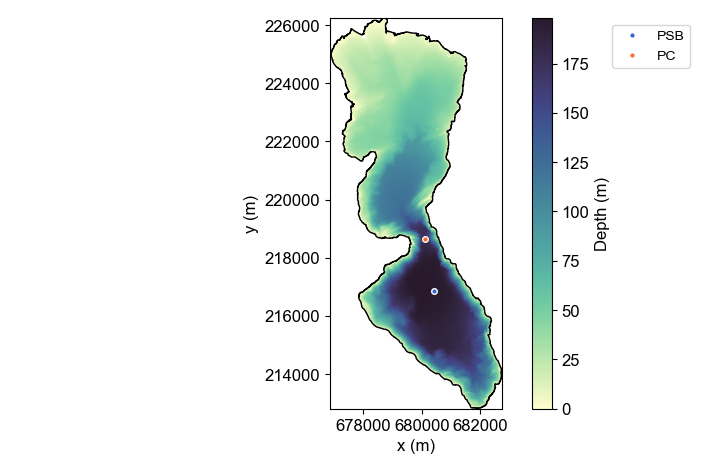

In [172]:
fig,ax = plt.subplots(1,1,figsize=(18 / 2.54, 12 / 2.54))  # Convert from cm to inches

hp=ax.pcolormesh(data_bathy.x-2e6, data_bathy.y-1e6,data_bathy.depth,vmin=0,vmax=np.nanmax(data_bathy.depth),cmap="cmo.deep",rasterized = True)
ax.plot(data_bathy.x_contour-2e6, data_bathy.y_contour-1e6, color='k', linewidth=1)
ax.set_aspect("equal")
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
cb = fig.colorbar(hp, ax=ax)
cb.set_label('Depth (m)')

# Add main locations:
for kc in range(len(indcat)-1):
    if len(indcat[kc])>0:
        ax.plot(int(dataprof[indcat[kc][0]].x_coord), int(dataprof[indcat[kc][0]].y_coord), marker='o', linestyle='', color=colcat[kc], markersize=4, 
        markeredgecolor='w',markeredgewidth=1,label=cat_label[kc])


# Add the microCTD profiles:
# for kf in range(len(fileprof)):
#     if 'x_coord' in dataprof[kf].attrs.keys() and 'y_coord' in dataprof[kf].attrs.keys():
#         ax.plot(int(dataprof[kf].x_coord), int(dataprof[kf].y_coord), marker='^', linestyle='', color=colmicro(kf), markersize=4, 
#                 markeredgecolor='w',markeredgewidth=1,label=profnames[kf]+' '+str(datetime_micro[kf].strftime('%H:%M')))

# Add the CTD profiles:
# for kCTD in range(len(dataprof_CTD_list)):
#     ax.plot(xcoord_CTD[kCTD], ycoord_CTD[kCTD], marker='o', linestyle='', color=colCTD(kCTD), markersize=4, 
#             markeredgecolor='w',markeredgewidth=1,label='CTD at '+profnames_CTD[kCTD]+' '+str(datetime_CTD[kCTD].strftime('%H:%M')))

# if plot_transect:
#     for kCTD in range(len(dataprof_CTDt.time)):
#         ax.plot(dataprof_CTDt.xcoord[kCTD], dataprof_CTDt.ycoord[kCTD], marker='s', linestyle='', color=colCTDt(kCTD), markersize=4, 
#                 markeredgecolor='w',markeredgewidth=1,label=dataprof_CTDt.profnames.values[kCTD]+' '+str(datetime_CTDt[kCTD].strftime('%H:%M')))


ax.legend(loc='upper left',bbox_to_anchor=(1.6, 1), fontsize=10)

fig.set_tight_layout(True)

if savefig:
    fig.savefig('map'+campaign_name+'.png',dpi=400)

In [20]:
fig.savefig('map_zoom'+campaign_name+'.png',dpi=400)

Plot the microCTD profiles

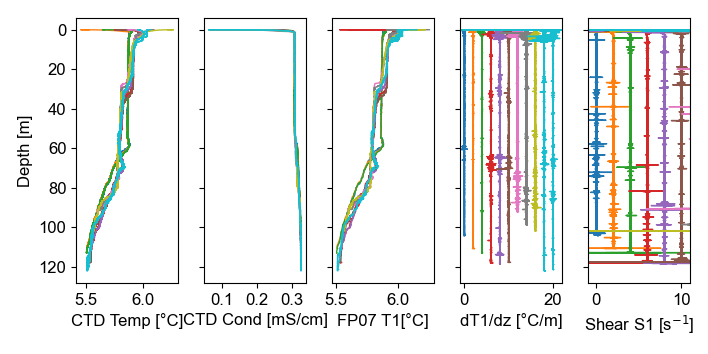

In [21]:

# Create a figure with specified size in centimeters
fig,ax = plt.subplots(1,5,figsize=(18 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches
Tsensor='T1'
Ssensor='S1'

for kf in range(len(dataprof)):
    ax[0].plot(dataprof[kf].SLOW_temperature.data,dataprof[kf].SLOW_depth,linewidth=1,color=colmicro(kf))
    
    ax[1].plot(dataprof[kf].SLOW_conductivity20.data/1000,dataprof[kf].SLOW_depth,linewidth=1,color=colmicro(kf))
    
    ax[2].plot(dataprof[kf]['FAST_fast_'+Tsensor].data,dataprof[kf].FAST_depth,linewidth=1,color=colmicro(kf))
    
    ax[3].plot(dataprof[kf]['FAST_grad_'+Tsensor].data+2*kf,dataprof[kf].FAST_depth,linewidth=1,color=colmicro(kf))
    
    ax[4].plot(dataprof[kf]['FAST_fast_'+Ssensor].data+2*kf,dataprof[kf].FAST_depth,linewidth=1,color=colmicro(kf))


# Labels and limits:
ax[0].set_ylabel('Depth [m]')
ax[0].set_xlabel('CTD Temp [°C]')
ax[1].set_xlabel('CTD Cond [mS/cm]')
ax[2].set_xlabel('FP07 '+Tsensor+'[°C]')
ax[3].set_xlabel('d'+Tsensor+'/dz [°C/m]')
ax[4].set_xlabel('Shear '+Ssensor+' [s$^{-1}$]')

ax[3].set_xlim(-1,2*len(dataprof))
ax[4].set_xlim(-1,len(dataprof))
ax[0].invert_yaxis()

fig.set_tight_layout(True)

if savefig:
    fig.savefig('comparison_prof_'+campaign_name+'.png',dpi=400)
    #fig.savefig('comparison_prof_'+campaign_name+'.svg',dpi=400)



Plot the turbulence data from the microCTD profiles

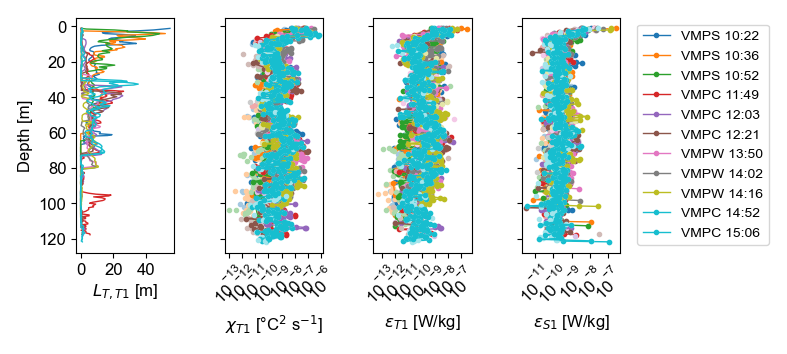

In [22]:

# Create a figure with specified size in centimeters
fig,ax = plt.subplots(1,4,figsize=(20 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches
Tsensor='T1'

for kf in range(len(dataprof)):
    pale_color = white_color_fraction * whitecol + (1-white_color_fraction) * np.array(colmicro(kf))
    
    indkeep_T=np.where(dataprof[kf]['BINNED_flag_'+Tsensor].data==0)[0]
    indkeep_S1=np.where(dataprof[kf].BINNED_flag_S1.data==0)[0]
    
    ax[0].plot(dataprof[kf]['BINNED_LTu'+Tsensor].data,dataprof[kf].BINNED_depth.data,'-',linewidth=1,color=colmicro(kf))
    
    ax[1].plot(dataprof[kf]['BINNED_Xi_'+Tsensor].data,dataprof[kf].BINNED_depth.data,'.',linewidth=1,color=pale_color)
    ax[1].plot(dataprof[kf]['BINNED_Xi_'+Tsensor].data[indkeep_T],dataprof[kf].BINNED_depth.data[indkeep_T],'.-',linewidth=1,color=colmicro(kf))
    
    ax[2].plot(dataprof[kf]['BINNED_eps_'+Tsensor].data,dataprof[kf].BINNED_depth.data,'.',linewidth=1,color=pale_color)
    ax[2].plot(dataprof[kf]['BINNED_eps_'+Tsensor].data[indkeep_T],dataprof[kf].BINNED_depth.data[indkeep_T],'.-',linewidth=1,color=colmicro(kf))
    
    ax[3].plot(dataprof[kf].BINNED_eps_S1.data,dataprof[kf].BINNED_depth.data,'.',linewidth=1,color=pale_color)
    ax[3].plot(dataprof[kf].BINNED_eps_S1.data[indkeep_S1],dataprof[kf].BINNED_depth.data[indkeep_S1],'.-',linewidth=1,color=colmicro(kf),label=profnames[kf]+' '+str(datetime_micro[kf].strftime('%H:%M')))
    
    
# Labels and limits:
ax[0].set_ylabel('Depth [m]')
ax[0].set_xlabel('$L_{T,'+Tsensor+'}$ [m]')
ax[1].set_xlabel('$\\chi_{'+Tsensor+'}$ [°C$^2$ s$^{-1}$]')
ax[2].set_xlabel('$\\varepsilon_{'+Tsensor+'}$ [W/kg]')
ax[3].set_xlabel('$\\varepsilon_{S1}$ [W/kg]')

xlimval=ax[0].get_xlim()
ax[0].set_xticks(np.arange(0, 100, 20))
ax[0].set_xlim(xlimval)

ax[1].set_xscale('log')
xlimval=ax[1].get_xlim()
ax[1].set_xticks(10.0**np.arange(-14, -5, 1))
ax[1].set_xlim(xlimval)
ax[1].tick_params(axis='x', labelrotation=45)

ax[2].set_xscale('log')
xlimval=ax[2].get_xlim()
ax[2].set_xticks(10.0**np.arange(-14, -5, 1))
ax[2].set_xlim(xlimval)
ax[2].tick_params(axis='x', labelrotation=45)

ax[3].set_xscale('log')
xlimval=ax[3].get_xlim()
ax[3].set_xticks(10.0**np.arange(-14, -5, 1))
ax[3].set_xlim(xlimval)
ax[3].tick_params(axis='x', labelrotation=45)

ax[0].invert_yaxis()

ax[3].legend(loc='upper left',bbox_to_anchor=(1.1, 1), fontsize=10)

fig.set_tight_layout(True)

if savefig:
    fig.savefig('comparison_turbulence_'+campaign_name+'.png',dpi=400)
    #fig.savefig('comparison_turbulence_'+campaign_name+'.svg',dpi=400)



Plot averaged turbulence profiles

In [ ]:
# Compute log-median profiles for the different categories, by keeping only bins without flags:
depthcell=5 # [m]

kt_mol=1.38e-07 # Molecular thermal diffusivity [m2/s], can be read from mat file or from L2 file if it is exported

plot_data=dict()
varlogmed=["LTu","eps_","Xi_","KOsbornCox_"]
indcat_withturb=[]
depth_list_badCox=[]
Kz_list_badCox=[]
for var in varlogmed:
    plot_data[var]={"depth_all":[], "values_all":[], "depth_cells":[], "logmed":[],"logq25":[],"logq75":[]}
    for kcat in range(len(categories)):
        if len(indcat[kcat])>0: # At least one profile in this category
            if var==varlogmed[0]: 
                indcat_withturb.append(kcat) # Save category index

            if var=="KOsbornCox_": # Only keep estimates with Cox number=Kz/kt>1
                depth_list_badCox.append([dataprof[i]["BINNED_depth"].values[(dataprof[i]["BINNED_flag_T1"].values==0)&(dataprof[i]["BINNED_"+var+"T1"].values<=kt_mol)] for i in indcat[kcat]])
                Kz_list_badCox.append([dataprof[i]["BINNED_"+var+"T1"].values[(dataprof[i]["BINNED_flag_T1"].values==0)&(dataprof[i]["BINNED_"+var+"T1"].values<=kt_mol)] for i in indcat[kcat]])
                depth_list=[dataprof[i]["BINNED_depth"].values[(dataprof[i]["BINNED_flag_T1"].values==0)&(dataprof[i]["BINNED_"+var+"T1"].values>kt_mol)] for i in indcat[kcat]]
                var_list=[dataprof[i]["BINNED_"+var+"T1"].values[(dataprof[i]["BINNED_flag_T1"].values==0)&(dataprof[i]["BINNED_"+var+"T1"].values>kt_mol)] for i in indcat[kcat]]
            else:
                depth_list=[dataprof[i]["BINNED_depth"].values[dataprof[i]["BINNED_flag_T1"].values==0] for i in indcat[kcat]]
                var_list=[dataprof[i]["BINNED_"+var+"T1"].values[dataprof[i]["BINNED_flag_T1"].values==0] for i in indcat[kcat]]

            depth_all, values_all, depth_cells, logmed,logq25,logq75 = compute_logmedian_list(depth_list,var_list,depthcell)
            # Include both T1 and T2:
            #depth_all, values_all, depth_cells, logmed = compute_logmedian_list([dataprof[i]["BINNED_depth"].values[dataprof[i]["BINNED_flag_T1"].values==0] for i in indcat[kcat]]+
                                                                                #[dataprof[i]["BINNED_depth"].values[dataprof[i]["BINNED_flag_T2"].values==0] for i in indcat[kcat]],
                                                                            # [dataprof[i]["BINNED_"+var+'T1'].values[dataprof[i]["BINNED_flag_T1"].values==0] for i in indcat[kcat]]+
                                                                                #[dataprof[i]["BINNED_"+var+'T2'].values[dataprof[i]["BINNED_flag_T2"].values==0] for i in indcat[kcat]], depthcell)
            plot_data[var]["depth_all"].append(depth_all)
            plot_data[var]["values_all"].append(values_all)
            plot_data[var]["depth_cells"].append(depth_cells)
            plot_data[var]["logmed"].append(logmed)
            plot_data[var]["logq25"].append(logq25)
            plot_data[var]["logq75"].append(logq75)

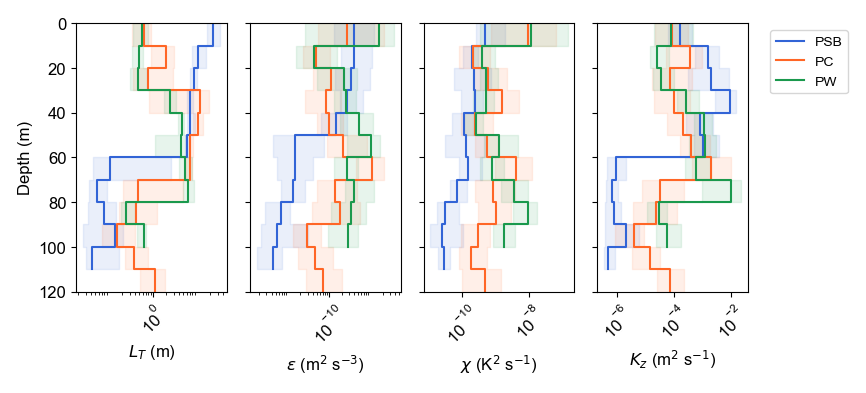

In [24]:
depthmax=120 # [m]

# Create a figure with specified size in centimeters
fig,ax = plt.subplots(1,4,figsize=(22 / 2.54, 10 / 2.54),sharey=True)  # Convert from cm to inches

# 1st subplot: Thorpe-T1
for kcat in range(len(plot_data["LTu"]["values_all"])):
        #ax[0].plot(plot_data["LTu"]["values_all"][kcat], plot_data["LTu"]["depth_all"][kcat], 'o', markersize=1, markeredgecolor=colcat_light[kcat], markerfacecolor=colcat_light[kcat],rasterized=True)
        ax[0].fill_betweenx(plot_data["LTu"]["depth_cells"][kcat],10**plot_data["LTu"]["logq25"][kcat], 10**plot_data["LTu"]["logq75"][kcat],color=colcat[kcat],alpha=0.1)
        ax[0].plot(10**plot_data["LTu"]["logmed"][kcat], plot_data["LTu"]["depth_cells"][kcat], '-', color=colcat[kcat])
ax[0].set_ylabel('Depth (m)')
ax[0].set_xlabel(r'$L_{T}$ (m)')
ax[0].set_xscale('log')
xlimval=ax[0].get_xlim()
ax[0].set_xticks(10.0**np.arange(-14, 1, 2))
ax[0].set_xlim(xlimval)
ax[0].tick_params(axis='x', labelrotation=45)

# 2nd subplot: Eps-T1
for kcat in range(len(plot_data["LTu"]["values_all"])):
        #ax[1].plot(plot_data["eps_"]["values_all"][kcat], plot_data["eps_"]["depth_all"][kcat], 'o', markersize=1, markeredgecolor=colcat_light[kcat], markerfacecolor=colcat_light[kcat],rasterized=True)
        ax[1].fill_betweenx(plot_data["eps_"]["depth_cells"][kcat],10**plot_data["eps_"]["logq25"][kcat], 10**plot_data["eps_"]["logq75"][kcat],color=colcat[kcat],alpha=0.1)
        ax[1].plot(10**plot_data["eps_"]["logmed"][kcat], plot_data["eps_"]["depth_cells"][kcat], '-', color=colcat[kcat])
ax[1].set_xlabel(r'$\epsilon$ (m$^2$ s$^{-3}$)')
ax[1].set_xscale('log')
xlimval=ax[1].get_xlim()
ax[1].set_xticks(10.0**np.arange(-14, 1, 2))
ax[1].set_xlim(xlimval)
ax[1].tick_params(axis='x', labelrotation=45)
#ax[1].set_xlim([10**(-11), 10**(-4)])


# 3rd subplot: X-T1
for kcat in range(len(plot_data["LTu"]["values_all"])):
        #ax[2].plot(plot_data["Xi_"]["values_all"][kcat], plot_data["Xi_"]["depth_all"][kcat], 'o', markersize=1, markeredgecolor=colcat_light[kcat], markerfacecolor=colcat_light[kcat],rasterized=True)
        ax[2].fill_betweenx(plot_data["Xi_"]["depth_cells"][kcat],10**plot_data["Xi_"]["logq25"][kcat], 10**plot_data["Xi_"]["logq75"][kcat],color=colcat[kcat],alpha=0.1)
        ax[2].plot(10**plot_data["Xi_"]["logmed"][kcat], plot_data["Xi_"]["depth_cells"][kcat], '-', color=colcat[kcat])
ax[2].set_xlabel(r'$\chi$ (K$^2$ s$^{-1}$)')
ax[2].set_xscale('log')
xlimval=ax[2].get_xlim()
ax[2].set_xticks(10.0**np.arange(-14, 1, 2))
ax[2].set_xlim(xlimval)
ax[2].tick_params(axis='x', labelrotation=45)
#ax[2].set_xlim([10**(-13), 10**(-6)])

# 4th subplot: Kz-T1
for kcat in range(len(plot_data["LTu"]["values_all"])):
        #ax[3].plot(plot_data["KOsbornCox_"]["values_all"][kcat], plot_data["KOsbornCox_"]["depth_all"][kcat], 'o', markersize=1, markeredgecolor=colcat_light[kcat], markerfacecolor=colcat_light[kcat],rasterized=True)
        ax[3].fill_betweenx(plot_data["KOsbornCox_"]["depth_cells"][kcat],10**plot_data["KOsbornCox_"]["logq25"][kcat], 10**plot_data["KOsbornCox_"]["logq75"][kcat],color=colcat[kcat],alpha=0.1)
        ax[3].plot(10**plot_data["KOsbornCox_"]["logmed"][kcat], plot_data["KOsbornCox_"]["depth_cells"][kcat], '-', color=colcat[kcat],label=cat_label[kcat])
ax[3].set_xlabel(r'$K_{z}$ (m$^2$ s$^{-1}$)')
ax[3].set_xscale('log')
xlimval=ax[3].get_xlim()
ax[3].set_xticks(10.0**np.arange(-14, 1, 2))
ax[3].set_xlim(xlimval)
ax[3].tick_params(axis='x', labelrotation=45)


ax[0].set_ylim((0,depthmax))
ax[0].invert_yaxis()  # Reverse the y-axis 
ax[3].legend(loc='upper left',bbox_to_anchor=(1.1, 1), fontsize=10)

fig.set_tight_layout(True)

# Save figure

if savefig:
    fig.savefig('comparison_turbulence_avg_'+campaign_name+'.png',dpi=400)
    #fig.savefig('comparison_turbulence_avg_'+campaign_name+'.svg',dpi=1000)



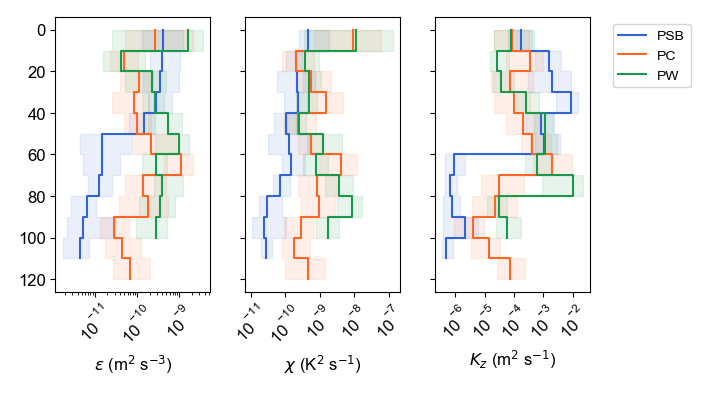

In [175]:

# Create a figure with specified size in centimeters
fig,ax = plt.subplots(1,3,figsize=(18 / 2.54, 10 / 2.54),sharey=True)  # Convert from cm to inches

# 1st subplot: Eps-T1
for kcat in range(len(plot_data["LTu"]["values_all"])):
        ax[0].fill_betweenx(plot_data["eps_"]["depth_cells"][kcat],10**plot_data["eps_"]["logq25"][kcat], 10**plot_data["eps_"]["logq75"][kcat],color=colcat[kcat],alpha=0.1)
        ax[0].plot(10**plot_data["eps_"]["logmed"][kcat], plot_data["eps_"]["depth_cells"][kcat], '-', color=colcat[kcat])
ax[0].set_xlabel(r'$\epsilon$ (m$^2$ s$^{-3}$)')
ax[0].set_xscale('log')
xlimval=ax[0].get_xlim()
ax[0].set_xticks(10.0**np.arange(-14, 1, 1))
ax[0].set_xlim(xlimval)
ax[0].tick_params(axis='x', labelrotation=45)
#ax[0].set_xlim([10**(-11), 10**(-4)])


# 2nd subplot: X-T1
for kcat in range(len(plot_data["LTu"]["values_all"])):
        ax[1].fill_betweenx(plot_data["Xi_"]["depth_cells"][kcat],10**plot_data["Xi_"]["logq25"][kcat], 10**plot_data["Xi_"]["logq75"][kcat],color=colcat[kcat],alpha=0.1)
        ax[1].plot(10**plot_data["Xi_"]["logmed"][kcat], plot_data["Xi_"]["depth_cells"][kcat], '-', color=colcat[kcat])
ax[1].set_xlabel(r'$\chi$ (K$^2$ s$^{-1}$)')
ax[1].set_xscale('log')
xlimval=ax[1].get_xlim()
ax[1].set_xticks(10.0**np.arange(-14, 1, 1))
ax[1].set_xlim(xlimval)
ax[1].tick_params(axis='x', labelrotation=45)
#ax[1].set_xlim([10**(-13), 10**(-6)])

# 3rd subplot: Kz-T1
for kcat in range(len(plot_data["LTu"]["values_all"])):
        ax[2].fill_betweenx(plot_data["KOsbornCox_"]["depth_cells"][kcat],10**plot_data["KOsbornCox_"]["logq25"][kcat], 10**plot_data["KOsbornCox_"]["logq75"][kcat],color=colcat[kcat],alpha=0.1)
        ax[2].plot(10**plot_data["KOsbornCox_"]["logmed"][kcat], plot_data["KOsbornCox_"]["depth_cells"][kcat], '-', color=colcat[kcat],label=cat_label[kcat])
ax[2].set_xlabel(r'$K_{z}$ (m$^2$ s$^{-1}$)')
ax[2].set_xscale('log')
xlimval=ax[2].get_xlim()
ax[2].set_xticks(10.0**np.arange(-14, 1, 1))
ax[2].set_xlim(xlimval)
ax[2].tick_params(axis='x', labelrotation=45)


ax[0].invert_yaxis()  # Reverse the y-axis 
ax[2].legend(loc='upper left',bbox_to_anchor=(1.1, 1), fontsize=10)

fig.set_tight_layout(True)

# Save figure

if savefig:
    fig.savefig('comparison_turbulence_avg_3loc_'+campaign_name+'.png',dpi=400)
    #fig.savefig('comparison_turbulence_avg_3loc_'+campaign_name+'.svg',dpi=1000)



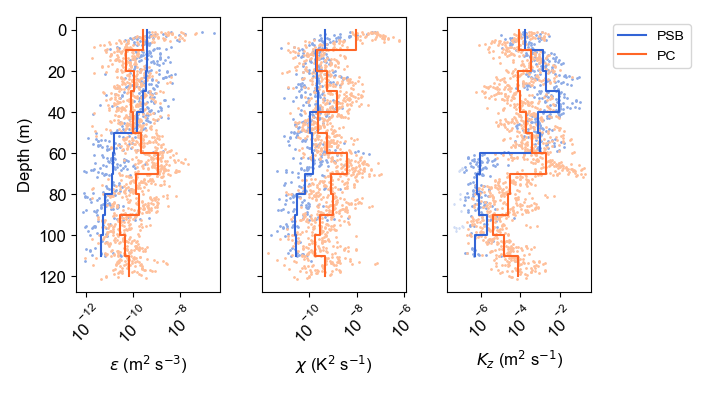

In [26]:
#depthmax=120 # [m]

#ind_prof_plot=range(len(plot_data["LTu"]["values_all"]))
ind_prof_plot=[0,1]


# Create a figure with specified size in centimeters
fig,ax = plt.subplots(1,3,figsize=(18 / 2.54, 10 / 2.54),sharey=True)  # Convert from cm to inches


# 1st subplot: Eps-T1
for kcat in ind_prof_plot:
        ax[0].plot(plot_data["eps_"]["values_all"][kcat], plot_data["eps_"]["depth_all"][kcat], 'o', markersize=1, markeredgecolor=colcat_light[kcat], markerfacecolor=colcat_light[kcat],rasterized=True)
for kcat in ind_prof_plot:
        ax[0].plot(10**plot_data["eps_"]["logmed"][kcat], plot_data["eps_"]["depth_cells"][kcat], '-', color=colcat[kcat])
ax[0].set_xlabel(r'$\epsilon$ (m$^2$ s$^{-3}$)')
ax[0].set_xscale('log')
xlimval=ax[0].get_xlim()
ax[0].set_xticks(10.0**np.arange(-14, 1, 2))
ax[0].set_xlim(xlimval)
ax[0].tick_params(axis='x', labelrotation=45)
#ax[0].set_xlim([10**(-11), 10**(-4)])


# 2nd subplot: X-T1
for kcat in ind_prof_plot:
        ax[1].plot(plot_data["Xi_"]["values_all"][kcat], plot_data["Xi_"]["depth_all"][kcat], 'o', markersize=1, markeredgecolor=colcat_light[kcat], markerfacecolor=colcat_light[kcat],rasterized=True)
for kcat in ind_prof_plot:
        ax[1].plot(10**plot_data["Xi_"]["logmed"][kcat], plot_data["Xi_"]["depth_cells"][kcat], '-', color=colcat[kcat])
ax[1].set_xlabel(r'$\chi$ (K$^2$ s$^{-1}$)')
ax[1].set_xscale('log')
xlimval=ax[1].get_xlim()
ax[1].set_xticks(10.0**np.arange(-14, 1, 2))
ax[1].set_xlim(xlimval)
ax[1].tick_params(axis='x', labelrotation=45)
#ax[1].set_xlim([10**(-13), 10**(-6)])

# 3rd subplot: Kz-T1
for kcat in ind_prof_plot:
        # Points with Cox number<1:
        col_light2=0.6 * whitecol[:3] + (1-0.6) * np.array(colcat_light[kcat])
        ax[2].plot(np.concatenate(Kz_list_badCox[kcat]),np.concatenate(depth_list_badCox[kcat]),'d', markersize=1, markeredgecolor=col_light2, markerfacecolor=col_light2,rasterized=True)
        ax[2].plot(plot_data["KOsbornCox_"]["values_all"][kcat], plot_data["KOsbornCox_"]["depth_all"][kcat], 'o', markersize=1, markeredgecolor=colcat_light[kcat], markerfacecolor=colcat_light[kcat],rasterized=True)
for kcat in ind_prof_plot:       
        ax[2].plot(10**plot_data["KOsbornCox_"]["logmed"][kcat], plot_data["KOsbornCox_"]["depth_cells"][kcat], '-', color=colcat[kcat],label=cat_label[kcat])
ax[2].set_xlabel(r'$K_{z}$ (m$^2$ s$^{-1}$)')
ax[2].set_xscale('log')
xlimval=ax[2].get_xlim()
ax[2].set_xticks(10.0**np.arange(-14, 1, 2))
ax[2].set_xlim(xlimval)
ax[2].tick_params(axis='x', labelrotation=45)

ax[0].set_ylabel('Depth (m)')  # Reverse the y-axis 
ax[0].invert_yaxis()  # Reverse the y-axis 
ax[2].legend(loc='upper left',bbox_to_anchor=(1.1, 1), fontsize=10)

fig.set_tight_layout(True)

# Save figure

if savefig:
    fig.savefig('comparison_turbulence_avg_2loc_'+campaign_name+'.png',dpi=400)
    #fig.savefig('comparison_turbulence_avg_2loc_'+campaign_name+'.svg',dpi=1000)



Plot individual CTD profiles

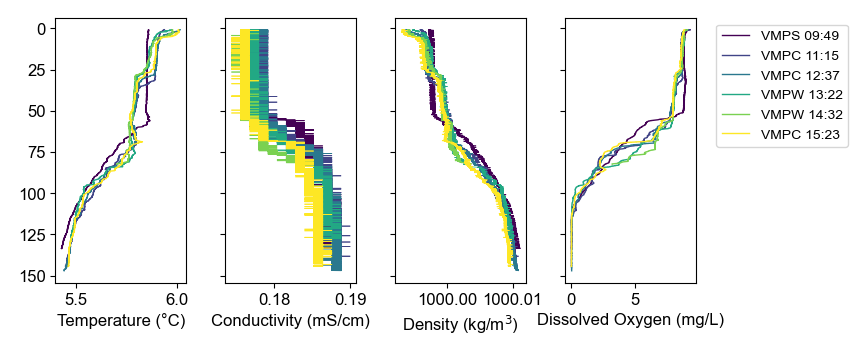

In [27]:
fig,ax = plt.subplots(1,4,figsize=(22 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches

# Plot CTD profiles
for kprof in range(len(dataprof_CTD_list)):
    ax[0].plot(dataprof_CTD_list[kprof]["Temp"].values, dataprof_CTD_list[kprof]["depth"].values, color=colCTD(kprof), linewidth=1)
    ax[1].plot(dataprof_CTD_list[kprof]["Cond"].values, dataprof_CTD_list[kprof]["depth"].values, color=colCTD(kprof), linewidth=0.5)
    ax[2].plot(dataprof_CTD_list[kprof]["rho"].values, dataprof_CTD_list[kprof]["depth"].values, color=colCTD(kprof), linewidth=0.5)
    ax[3].plot(dataprof_CTD_list[kprof]["DO_mg"].values, dataprof_CTD_list[kprof]["depth"].values, color=colCTD(kprof), linewidth=1,label=profnames_CTD[kprof]+' '+str(datetime_CTD[kprof].strftime('%H:%M')))
    
ax[0].set_xlabel('Temperature (°C)')
ax[1].set_xlabel('Conductivity (mS/cm)')
ax[2].set_xlabel('Density (kg/m$^3$)')
ax[2].ticklabel_format(useOffset=False, style='plain', axis='x')
ax[3].set_xlabel('Dissolved Oxygen (mg/L)')
ax[0].invert_yaxis()  # Reverse the y-axis 

ax[3].legend(loc='upper left',bbox_to_anchor=(1.1, 1), fontsize=10)

fig.set_tight_layout(True)

# Save figure

if savefig:
    fig.savefig('CTD_profiles_'+campaign_name+'.png',dpi=400)
    fig.savefig('CTD_profiles_'+campaign_name+'.svg',dpi=1000)

    


Plot CTD profiles from transect

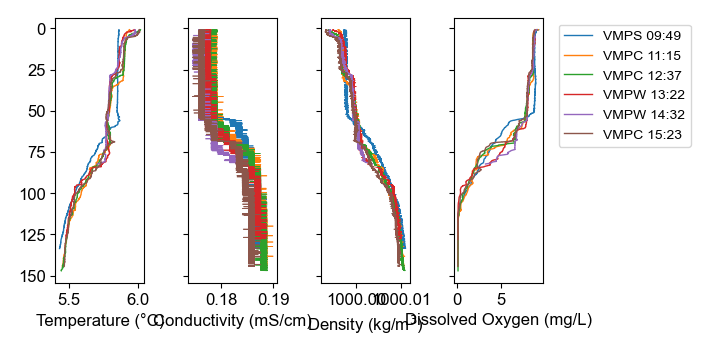

In [15]:

if plot_transect:

    fig,ax = plt.subplots(1,4,figsize=(18 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches

    # Plot CTD profiles
    for kprof in range(len(dataprof_CTDt.time)):
        ax[0].plot(dataprof_CTDt["temp"].values[:,kprof], dataprof_CTDt["depth"].values, color=colCTDt(kprof), linewidth=1)
        ax[1].plot(dataprof_CTDt["cond"].values[:,kprof], dataprof_CTDt["depth"].values, color=colCTDt(kprof), linewidth=0.5)
        ax[2].plot(dataprof_CTDt["rho"].values[:,kprof], dataprof_CTDt["depth"].values, color=colCTDt(kprof), linewidth=0.5)
        ax[3].plot(dataprof_CTDt["DO"].values[:,kprof], dataprof_CTDt["depth"].values, color=colCTDt(kprof), linewidth=1,label=profnames_CTDt[kprof]+' '+str(datetime_CTDt[kprof].strftime('%H:%M')))
        
    ax[0].set_xlabel('Temperature (°C)')
    ax[1].set_xlabel('Conductivity (mS/cm)')
    ax[2].set_xlabel('Density (kg/m$^3$)')
    ax[2].ticklabel_format(useOffset=False, style='plain', axis='x')
    ax[3].set_xlabel('Dissolved Oxygen (mg/L)')
    ax[0].invert_yaxis()  # Reverse the y-axis 

    ax[3].legend(loc='upper left',bbox_to_anchor=(1.1, 1), fontsize=10)


    fig.set_tight_layout(True)

    # Save figure

    if savefig:
        fig.savefig('CTD_profiles_transect_'+campaign_name+'.png',dpi=400)
        fig.savefig('CTD_profiles_transect_'+campaign_name+'.svg',dpi=1000)

    


Plot CTD profiles for 2 locations

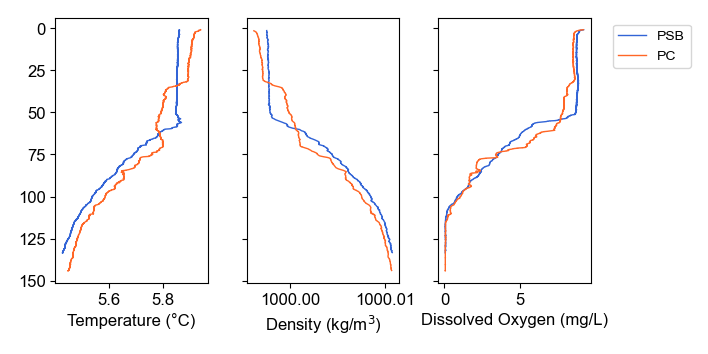

In [16]:
fig,ax = plt.subplots(1,3,figsize=(18 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches
indprof_plot=[0,0,-1] # Profile index to show for each location
# Plot CTD profiles
counter=0
for kcat in [0,1]:
    if counter==2:
        lnstyle='--'
    else:
        lnstyle='-'
    ax[0].plot(dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][indprof_plot[counter]]]["Temp"].values,dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][indprof_plot[counter]]]["depth"].values, lnstyle, color=colcat[indcat_withCTD[kcat]], linewidth=1)
    rho_smooth=movmean(dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][indprof_plot[counter]]]["rho"].values,40)
    ax[1].plot(rho_smooth, dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][indprof_plot[counter]]]["depth"].values, lnstyle, color=colcat[indcat_withCTD[kcat]], linewidth=1)
    ax[2].plot(dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][indprof_plot[counter]]]["DO_mg"].values, dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][indprof_plot[counter]]]["depth"].values, lnstyle, color=colcat[indcat_withCTD[kcat]], linewidth=1, label=cat_label[indcat_withturb[kcat]])
    counter+=1
ax[0].set_xlabel('Temperature (°C)')
ax[1].set_xlabel('Density (kg/m$^3$)')
ax[1].ticklabel_format(useOffset=False, style='plain', axis='x')
ax[2].set_xlabel('Dissolved Oxygen (mg/L)') 
ax[0].invert_yaxis()  # Reverse the y-axis

ax[2].legend(loc='upper left',bbox_to_anchor=(1.1, 1), fontsize=10)

fig.set_tight_layout(True)

# Save figure

if savefig:
    fig.savefig('CTD_profiles_2locations_'+campaign_name+'.png',dpi=400)
    fig.savefig('CTD_profiles_2locations_'+campaign_name+'.svg',dpi=1000)

Zoom on 2 profiles

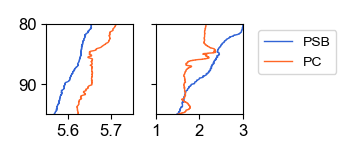

In [17]:
fig,ax = plt.subplots(1,2,figsize=(9 / 2.54, 4 / 2.54),sharey=True)  # Convert from cm to inches
indprof_plot=[0,0,-1] # Profile index to show for each location
# Plot CTD profiles
counter=0
for kcat in [0,1]:
    if counter==2:
        lnstyle='--'
    else:
        lnstyle='-'
    ax[0].plot(dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][indprof_plot[counter]]]["Temp"].values,dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][indprof_plot[counter]]]["depth"].values, lnstyle, color=colcat[indcat_withCTD[kcat]], linewidth=1)
    ax[1].plot(dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][indprof_plot[counter]]]["DO_mg"].values, dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][indprof_plot[counter]]]["depth"].values, lnstyle, color=colcat[indcat_withCTD[kcat]], linewidth=1, label=cat_label[indcat_withturb[kcat]])
    counter+=1
#ax[0].set_xlabel('Temperature (°C)')
#ax[1].set_xlabel('Dissolved Oxygen (mg/L)') 
ax[0].set_ylim(80,95)
ax[0].set_xlim(5.55,5.75)
ax[1].set_xlim(1,3)
ax[0].invert_yaxis()  # Reverse the y-axis

ax[1].legend(loc='upper left',bbox_to_anchor=(1.1, 1), fontsize=10)

fig.set_tight_layout(True)

# Save figure

if savefig:
    zoom_str='zoom_'
    fig.savefig('CTD_profiles_2locations_'+zoom_str+campaign_name+'.png',dpi=400)
    fig.savefig('CTD_profiles_2locations_'+zoom_str+campaign_name+'.svg',dpi=1000)

Plot CTD profiles for 3 locations

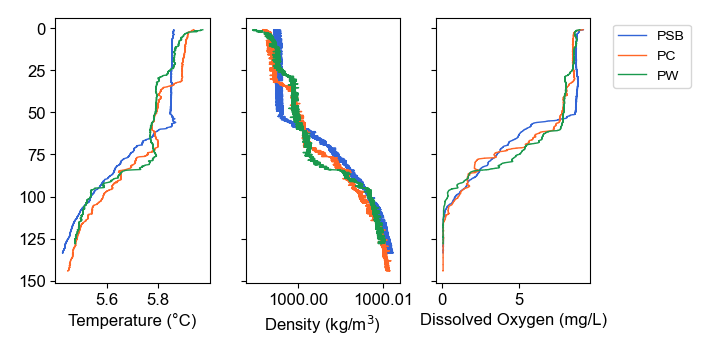

In [18]:
fig,ax = plt.subplots(1,3,figsize=(18 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches
indprof_plot=[0,0,0] # Profile index to show for each location
# Plot CTD profiles
for kcat in range(len(indcat_withCTD)):
    ax[0].plot(dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][indprof_plot[kcat]]]["Temp"].values,dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][indprof_plot[kcat]]]["depth"].values, color=colcat[indcat_withCTD[kcat]], linewidth=1)
    ax[1].plot(dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][indprof_plot[kcat]]]["rho"].values, dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][indprof_plot[kcat]]]["depth"].values, color=colcat[indcat_withCTD[kcat]], linewidth=1)
    ax[2].plot(dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][indprof_plot[kcat]]]["DO_mg"].values, dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][indprof_plot[kcat]]]["depth"].values, color=colcat[indcat_withCTD[kcat]], linewidth=1, label=cat_label[indcat_withturb[kcat]])

ax[0].set_xlabel('Temperature (°C)')
ax[1].set_xlabel('Density (kg/m$^3$)')
ax[1].ticklabel_format(useOffset=False, style='plain', axis='x')
ax[2].set_xlabel('Dissolved Oxygen (mg/L)')
ax[0].invert_yaxis()  # Reverse the y-axis 

ax[2].legend(loc='upper left',bbox_to_anchor=(1.1, 1), fontsize=10)

fig.set_tight_layout(True)

# Save figure

if savefig:
    fig.savefig('CTD_profiles_3locations_'+campaign_name+'.png',dpi=400)
    fig.savefig('CTD_profiles_3locations_'+campaign_name+'.svg',dpi=1000)

Plot temp-DO profiles or density-DO profiles

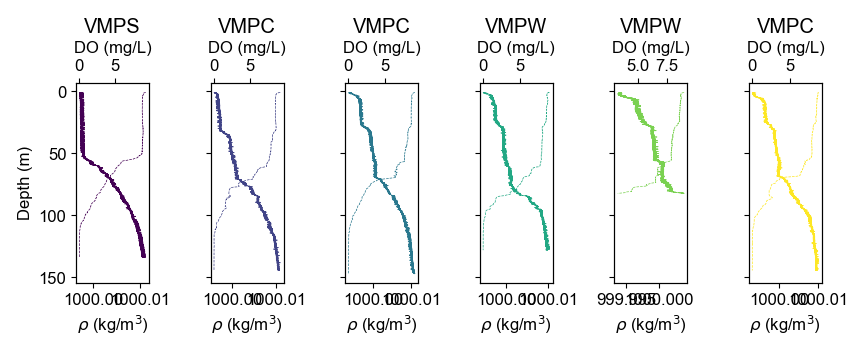

In [19]:


# Plot CTD profiles from transect
# fig,ax = plt.subplots(1,len(dataprof_CTDt.time),figsize=(22 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches

# for kprof in range(len(dataprof_CTDt.time)):
#     ax[kprof].plot(dataprof_CTDt["rho"].values[:,kprof], dataprof_CTDt["depth"].values, color=colCTD(kprof), linewidth=0.5)
#     ax2=ax[kprof].twiny()
#     ax2.plot(dataprof_CTDt["DO"].values[:,kprof], dataprof_CTDt["depth"].values, '--', color=colCTD(kprof), linewidth=0.5)
#     ax[kprof].set_xlabel('$\\rho$ (kg/m$^3$)')
#     ax2.set_xlabel('DO (mg/L)')
#     ax[kprof].set_title(dataprof_CTDt.profnames.values[kprof])

#     ax[kprof].ticklabel_format(useOffset=False, style='plain', axis='x')

# Plot individual CTD profiles:
fig,ax = plt.subplots(1,len(dataprof_CTD_list),figsize=(22 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches

for kprof in range(len(dataprof_CTD_list)):
    #ax[kprof].plot(dataprof_CTD["temp"].values[:,kprof], dataprof_CTD["depth"].values, color=colCTD(kprof), linewidth=0.5)
    ax[kprof].plot(dataprof_CTD_list[kprof]["rho"].values, dataprof_CTD_list[kprof]["depth"].values, color=colCTD(kprof), linewidth=0.5)
    ax2=ax[kprof].twiny()
    ax2.plot(dataprof_CTD_list[kprof]["DO_mg"].values, dataprof_CTD_list[kprof]["depth"].values, '--', color=colCTD(kprof), linewidth=0.5)
    
    #ax[kprof].set_xlabel('T (°C)')
    ax[kprof].set_xlabel('$\\rho$ (kg/m$^3$)')
    ax2.set_xlabel('DO (mg/L)')
    ax[kprof].set_title(profnames_CTD[kprof])
    ax[kprof].ticklabel_format(useOffset=False, style='plain', axis='x')



ax[0].invert_yaxis()  # Reverse the y-axis
ax[0].set_ylabel('Depth (m)') 


fig.set_tight_layout(True)

# Save figure

if savefig:
    fig.savefig('CTD_profiles_tempDO_'+campaign_name+'.png',dpi=400)
    #fig.savefig('CTD_profiles_tempDO_'+campaign_name+'.svg',dpi=1000)



Plot temperature and oxygen displacements

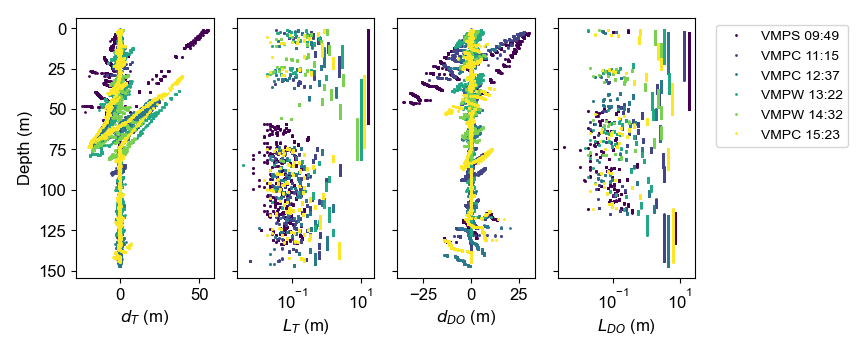

In [20]:
fig,ax = plt.subplots(1,4,figsize=(22 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches

# Plot CTD profiles
for kprof in range(len(dataprof_CTD_list)):
    ax[0].plot(dataprof_CTD_list[kprof]["thorpe_disp"].values, dataprof_CTD_list[kprof]["depth"].values, '.',markersize=2,color=colCTD(kprof))
    ax[1].plot(dataprof_CTD_list[kprof]["Lt"].values, dataprof_CTD_list[kprof]["depth"].values, '.',markersize=2,color=colCTD(kprof))
    ax[2].plot(dataprof_CTD_list[kprof]["DO_disp"].values, dataprof_CTD_list[kprof]["depth"].values, '.',markersize=2,color=colCTD(kprof))
    ax[3].plot(dataprof_CTD_list[kprof]["Lt_DO"].values, dataprof_CTD_list[kprof]["depth"].values, '.',markersize=2,color=colCTD(kprof),
    label=profnames_CTD[kprof]+' '+str(datetime_CTD[kprof].strftime('%H:%M')))
   
ax[0].set_ylabel('Depth (m)')
ax[0].set_xlabel('$d_{T}$ (m)')
ax[1].set_xlabel('$L_{T}$ (m)')
ax[1].set_xscale('log')
ax[2].set_xlabel('$d_{DO}$ (m)')
ax[3].set_xlabel('$L_{DO}$ (m)')
ax[3].set_xscale('log')
ax[0].invert_yaxis()  # Reverse the y-axis 

ax[3].legend(loc='upper left',bbox_to_anchor=(1.1, 1), fontsize=10)

fig.set_tight_layout(True)

# Save figure

if savefig:
    fig.savefig('CTD_displacements_'+campaign_name+'.png',dpi=400)
    fig.savefig('CTD_displacements_'+campaign_name+'.svg',dpi=1000)

Displacements for each location

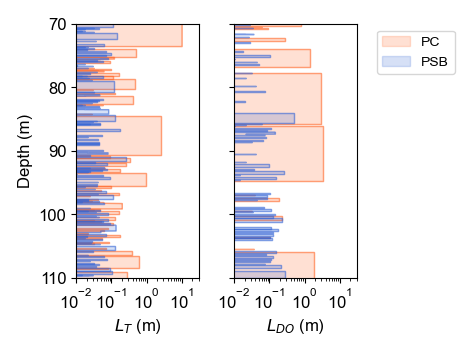

In [21]:
xlim_L=10**np.array([-2,1.5])
# Create a figure with specified size in centimeters
fig,ax = plt.subplots(1,2,figsize=(12 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches


# 1st plot: LT
for kcat in [1,0]:
    Ltval=dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][0]]["Lt"]
    mask = ~np.isnan(Ltval)

    ax[0].fill_betweenx(dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][0]]["depth"],xlim_L[0]-1, Ltval,        # 1e-6 because log scale cannot start at 0
                        where=mask,color=colcat[indcat_withCTD[kcat]],alpha=0.2)
    ax[0].fill_betweenx(dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][0]]["depth"],xlim_L[0]-1, Ltval,        # 1e-6 because log scale cannot start at 0
                        where=mask,color=colcat[indcat_withCTD[kcat]],facecolor='none',edgecolor=colcat[indcat_withCTD[kcat]],alpha=0.5)

ax[0].set_xlabel('$L_T$ (m)')
ax[0].set_xscale('log')
ax[0].set_xlim(xlim_L[0],xlim_L[1])


# 2nd subplot: DO displacements length
for kcat in [1,0]:
    Ltval=dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][0]]["Lt_DO"]
    mask = ~np.isnan(Ltval)

    ax[1].fill_betweenx(dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][0]]["depth"],xlim_L[0]-1, Ltval,        # 1e-6 because log scale cannot start at 0
                        where=mask,color=colcat[indcat_withCTD[kcat]],alpha=0.2,label=cat_label[indcat_withturb[kcat]])
    ax[1].fill_betweenx(dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][0]]["depth"],xlim_L[0]-1, Ltval,        # 1e-6 because log scale cannot start at 0
                        where=mask,color=colcat[indcat_withCTD[kcat]],facecolor='none',edgecolor=colcat[indcat_withCTD[kcat]],alpha=0.5) 
ax[1].set_xlabel('$L_{DO}$ (m)')
ax[1].set_xscale('log')
ax[1].set_xlim(xlim_L[0],xlim_L[1])

ax[0].set_ylim(70,110)
ax[0].invert_yaxis()  # Reverse the y-axis 
ax[0].set_ylabel('Depth (m)')
ax[1].legend(loc='upper left',bbox_to_anchor=(1.1, 1), fontsize=10)
fig.set_tight_layout(True)

# Save figure

if savefig:
    fig.savefig('displacements_'+campaign_name+'.png',dpi=400)
    #fig.savefig('displacements_'+campaign_name+'.svg',dpi=400)

Plot turbulence and DO on the same figure

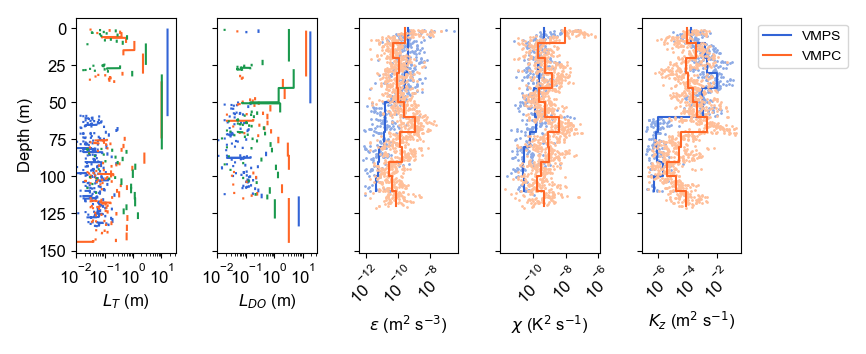

In [22]:
xlim_L=10**np.array([-2,1.5])
# Create a figure with specified size in centimeters
fig,ax = plt.subplots(1,5,figsize=(22 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches


# 1st plot: fast temperature
# for kcat in range(len(indcat_withturb)):
#     ax[0].plot(dataprof[indcat[indcat_withturb[kcat]][0]].FAST_fast_T1.data,dataprof[indcat[indcat_withturb[kcat]][0]].FAST_depth,linewidth=1.5, color=colcat[indcat_withturb[kcat]])
# ax[0].set_xlabel('Fast T1 (°C)')

# 1st plot: LT
for kcat in range(len(indcat_withCTD)):
    ax[0].plot(dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][0]]["Lt"],dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][0]]["depth"],'-',linewidth=1.5, color=colcat[indcat_withCTD[kcat]])
ax[0].set_xlabel('$L_T$ (m)')
ax[0].set_xscale('log')
ax[0].set_xlim(xlim_L[0],xlim_L[1])


# 2nd subplot: DO concentration
# for kcat in range(len(indcat_withCTD)):
#     ax[1].plot(dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][0]]["DO_mg"],dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][0]]["depth"],'-',linewidth=1.5, color=colcat[indcat_withCTD[kcat]])
# ax[1].set_xlabel('DO (mg L$^{-1}$)')

# 2nd subplot: DO displacements length
for kcat in range(len(indcat_withCTD)):
    ax[1].plot(dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][0]]["Lt_DO"],dataprof_CTD_list[indcat_CTD[indcat_withCTD[kcat]][0]]["depth"],'-',linewidth=1.5, color=colcat[indcat_withCTD[kcat]])
ax[1].set_xlabel('$L_{DO}$ (m)')
ax[1].set_xscale('log')
ax[1].set_xlim(xlim_L[0],xlim_L[1])


# 2nd subplot: Eps-T1
for kcat in range(len(indcat_withturb)-1):
    ax[2].plot(plot_data["eps_"]["values_all"][kcat], plot_data["eps_"]["depth_all"][kcat], 'o', markersize=1, markeredgecolor=colcat_light[indcat_withturb[kcat]], markerfacecolor=colcat_light[indcat_withturb[kcat]],rasterized=True)
    ax[2].plot(10**plot_data["eps_"]["logmed"][kcat], plot_data["eps_"]["depth_cells"][kcat], '-', color=colcat[indcat_withturb[kcat]],label=categories[indcat_withturb[kcat]])
ax[2].set_xlabel(r'$\epsilon$ (m$^2$ s$^{-3}$)')
ax[2].set_xscale('log')
xlimval=ax[2].get_xlim()
ax[2].set_xticks(10.0**np.arange(-14, 1, 2))
ax[2].set_xlim(xlimval)
ax[2].tick_params(axis='x', labelrotation=45)
#ax[2].set_xlim([10**(-11), 10**(-4)])


# 2nd subplot: X-T1
for kcat in range(len(indcat_withturb)-1):
    ax[3].plot(plot_data["Xi_"]["values_all"][kcat], plot_data["Xi_"]["depth_all"][kcat], 'o', markersize=1, markeredgecolor=colcat_light[indcat_withturb[kcat]], markerfacecolor=colcat_light[indcat_withturb[kcat]],rasterized=True)
    ax[3].plot(10**plot_data["Xi_"]["logmed"][kcat], plot_data["Xi_"]["depth_cells"][kcat], '-', color=colcat[indcat_withturb[kcat]],label=categories[indcat_withturb[kcat]]) 
ax[3].set_xlabel(r'$\chi$ (K$^2$ s$^{-1}$)')
ax[3].set_xscale('log')
xlimval=ax[3].get_xlim()
ax[3].set_xticks(10.0**np.arange(-14, 1, 2))
ax[3].set_xlim(xlimval)
ax[3].tick_params(axis='x', labelrotation=45)
#ax[2].set_xlim([10**(-13), 10**(-6)])

# 3rd subplot: Kz-T1
for kcat in range(len(indcat_withturb)-1):
    ax[4].plot(plot_data["KOsbornCox_"]["values_all"][kcat], plot_data["KOsbornCox_"]["depth_all"][kcat], 'o', markersize=1, markeredgecolor=colcat_light[indcat_withturb[kcat]], markerfacecolor=colcat_light[indcat_withturb[kcat]],rasterized=True)
    ax[4].plot(10**plot_data["KOsbornCox_"]["logmed"][kcat], plot_data["KOsbornCox_"]["depth_cells"][kcat], '-', color=colcat[indcat_withturb[kcat]],label=categories[indcat_withturb[kcat]])
ax[4].set_xlabel(r'$K_{z}$ (m$^2$ s$^{-1}$)')
ax[4].set_xscale('log')
xlimval=ax[4].get_xlim()
ax[4].set_xticks(10.0**np.arange(-14, 1, 2))
ax[4].set_xlim(xlimval)
ax[4].tick_params(axis='x', labelrotation=45)
ax[4].legend(loc='upper left',bbox_to_anchor=(1.1, 1), fontsize=10)
ax[0].set_ylabel('Depth (m)')

ax[0].invert_yaxis()  # Reverse the y-axis 

fig.set_tight_layout(True)

# Save figure

if savefig:
    fig.savefig('comparison_turbulence_DO_'+campaign_name+'.png',dpi=400)
    #fig.savefig('comparison_turbulence_DO_'+campaign_name+'.svg',dpi=400)

Gradient Richardson

In [169]:
# Gradient Richardson number
g=9.81
rho0=1000
depth1=data_vel1.range.values[~np.isnan(data_vel1.vel[:,1])]
vel1_smooth=movmean(data_vel1.vel.values[~np.isnan(data_vel1.vel[:,1]),1],5).transpose()[0]
rho1=np.interp(depth1,dataprof_CTD_list[indcat_CTD[1][0]]["depth"].values,
               movmean(dataprof_CTD_list[indcat_CTD[1][0]]["rho"].values,40).transpose()[0],left=np.nan,right=np.nan)

Rig1=g/rho0*np.diff(rho1)/(depth1[1]-depth1[0])/(np.diff(vel1_smooth)/(depth1[1]-depth1[0]))**2

depth2=data_vel2.range.values[~np.isnan(data_vel2.vel[:,1])]
vel2_smooth=movmean(data_vel2.vel.values[~np.isnan(data_vel2.vel[:,1]),1],5).transpose()[0]
rho2=np.interp(depth2,dataprof_CTD_list[indcat_CTD[1][1]]["depth"].values,
               movmean(dataprof_CTD_list[indcat_CTD[1][1]]["rho"].values,40).transpose()[0],left=np.nan,right=np.nan)

Rig2=g/rho0*np.diff(rho2)/(depth2[1]-depth2[0])/(np.diff(vel2_smooth)/(depth2[1]-depth2[0]))**2

depth3=data_vel3.range.values[~np.isnan(data_vel3.vel[:,1])]
vel3_smooth=movmean(data_vel3.vel.values[~np.isnan(data_vel3.vel[:,1]),1],5).transpose()[0]
rho3=np.interp(depth3,dataprof_CTD_list[indcat_CTD[1][1]]["depth"].values,
               movmean(dataprof_CTD_list[indcat_CTD[1][1]]["rho"].values,40).transpose()[0],left=np.nan,right=np.nan)

Rig3=g/rho0*np.diff(rho3)/(depth3[1]-depth3[0])/(np.diff(vel3_smooth)/(depth3[1]-depth3[0]))**2



#depth_all_Rig, values_all_Rig, depth_cells_Rig, logmed_Rig,logq25_Rig,logq75_Rig = compute_logmedian_list([depth1[:-1],depth2[:-1],depth3[:-1]],[Rig1,Rig2,Rig3],1)
Rig_all=np.concatenate([Rig1,Rig2,Rig3])
# Remove outliers:
depth_all=np.concatenate([depth1[:-1],depth2[:-1],depth3[:-1]])[(Rig_all<1e3)&(Rig_all>0)&(~np.isnan(Rig_all))]
Rig_all=Rig_all[(Rig_all<1e3)&(Rig_all>0)&(~np.isnan(Rig_all))]
indsort_Rig=np.argsort(depth_all)
logmean_Rig=movmean(np.log10(Rig_all[indsort_Rig]),10)
depth_sort=depth_all[indsort_Rig]

C:\Users\tdoda\AppData\Local\Temp\ipykernel_12472\3705692085.py:16: RuntimeWarning: divide by zero encountered in divide
  Rig2=g/rho0*np.diff(rho2)/(depth2[1]-depth2[0])/(np.diff(vel2_smooth)/(depth2[1]-depth2[0]))**2
C:\Users\tdoda\AppData\Local\Temp\ipykernel_12472\3705692085.py:23: RuntimeWarning: divide by zero encountered in divide
  Rig3=g/rho0*np.diff(rho3)/(depth3[1]-depth3[0])/(np.diff(vel3_smooth)/(depth3[1]-depth3[0]))**2


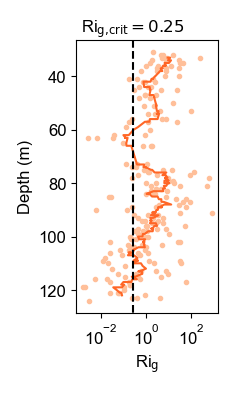

In [170]:
# Plot profile
fig,ax = plt.subplots(1,1,figsize=(6 / 2.54, 10 / 2.54))  # Convert from cm to inches
ax.plot(Rig_all,depth_all,'.',color=colcat_light[1])
ax.plot(10**logmean_Rig,depth_sort,'-',color=colcat[1],linewidth=1.5)
ylimval=ax.get_ylim()
ax.plot([0.25,0.25],[ylimval[0],ylimval[-1]],'--k')
ax.set_ylim(ylimval)
ax.text(0.25,ylimval[0],'Ri$_\\text{g,crit} = 0.25$',va='bottom',ha='center')
ax.set_xscale('log')
xlimval=ax.get_xlim()
ax.set_xticks(10.0**np.arange(-6,6,2))
ax.set_xlim(xlimval)
ax.invert_yaxis()
ax.set_xlabel('Ri$_\\text{g}$')
ax.set_ylabel('Depth (m)')

fig.set_tight_layout(True)

if savefig:
    fig.savefig('Rig_constriction_'+campaign_name+'.png',dpi=400)
    #fig.savefig('Rig_constriction_'+campaign_name+'.svg',dpi=400)

Other dimensionless numbers

In [3]:
# Exchange flows regime (Hogg et al., 2001)
g=9.81 # [m s-2]
H=170 # [m]
L=13000 # [m]
drho=0.01 # [kg m-3]
Kz=1e-4 # [m2 s-1]
rho0=1000 # [kg m-3]
gprime=g*drho/rho0
GrtA2=gprime*H**5/(L**2*Kz**2)
print("GrA2 = {:.3e}".format(GrtA2))

# Similar number for advection instead of buoyancy forces: Péclet
U=0.01 # [m/s]
kt_mol=1.38e-07
Pe=U*H/Kz
Cx=Kz/kt_mol # Cox number
print("Pe = {:.3e}, PeCx = {:.3e}".format(Pe,Pe*Cx))

# Reynolds
nu=1.5e-6 # [m^2/s]
Re=U*H/nu
print("Re = {:.3e}".format(Re))

# Composite Froude number (2 layers)
rho1=1000
rho2=1000.005
U1=U
U2=U
h1=70
gprime12=g*(rho2-rho1)/rho0
F1=U1/np.sqrt(gprime12*h1)
F2=U2/np.sqrt(gprime12*(H-h1))

print("F1 = {:.2f}, F2={:.2f}".format(F1,F2))


GrA2 = 8.242e+06
Pe = 1.700e+04, PeCx = 1.232e+07
Re = 1.133e+06
F1 = 0.17, F2=0.14


In [1]:
0.17**2+0.14**2

0.04850000000000001

Overturning timescales

In [37]:
Kz=1e-4
l=3
U=0.05
tdiff=l**2/Kz 
Ldiff=U*tdiff
print("tdiff={:.1f} h, L={:.0f} m".format(tdiff/3600,Ldiff))

tdiff=25.0 h, L=4500 m


In [38]:
Kz=1e-6
l=1
U=0.001
tdiff=l**2/Kz 
Ldiff=U*tdiff
print("tdiff={:.1f} d, L={:.0f} m".format(tdiff/86400,Ldiff))

tdiff=11.6 d, L=1000 m
